# Paired TCREmp on VDJdb Full

This notebook analyzes paired TRA/TRB embeddings from `vdjdb_full.txt.gz` in two modes:

1. Strict paired rows already containing both chains.
2. The same human VDJdb rows after single-chain records are repaired with missing-chain imputation.

The paired embedding is a direct concatenation of chain-specific TCREmp embeddings.

In [1]:
# Configure imports, plotting, randomness, and print environment versions.
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import sklearn
import umap
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, normalize as l2normalize

try:
    import kneed
    from kneed import KneeLocator
except ImportError:
    kneed = None
    KneeLocator = None

from mir.common.parser import VDJdbFullPairedParser
from mir.common.single_cell import build_tenx_sample_from_cell_clonotypes
from mir.common.single_cell_repair import impute_missing_chains
from mir.embedding.tcremp import PairedTCREmp
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_full, find_repo_root

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='talk')

print(f'Python: {sys.version.split()[0]}')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'polars: {pl.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'umap-learn: {umap.__version__}')
print(f'kneed: {getattr(kneed, "__version__", "not-installed")}')

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.12
numpy: 2.4.4
pandas: 2.3.3
polars: 1.39.3
scikit-learn: 1.8.0
umap-learn: 0.5.12
kneed: 0.8.6


In [2]:
# Load VDJdb full rows, build strict paired data, and build an imputed paired variant.
repo_root = find_repo_root(Path.cwd())
dataset_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=['vdjdb/**'])
vdjdb_full = find_airr_benchmark_vdjdb_full(dataset_root)
parser = VDJdbFullPairedParser()

t0 = time.perf_counter()
strict_cell_df, strict_metadata = parser.parse_cell_clonotypes_file(
    vdjdb_full,
    sample_id='vdjdb_full_human_strict',
    species='HomoSapiens',
    include_incomplete=False,
)
strict_sample = build_tenx_sample_from_cell_clonotypes(
    strict_cell_df,
    sample_id='vdjdb_full_human_strict',
    barcode_metadata=strict_metadata,
)
strict_runtime = time.perf_counter() - t0

t0 = time.perf_counter()
impute_input_df, impute_metadata = parser.parse_cell_clonotypes_file(
    vdjdb_full,
    sample_id='vdjdb_full_human_impute',
    species='HomoSapiens',
    include_incomplete=True,
)
imputed_cell_df = impute_missing_chains(impute_input_df)
imputed_sample = build_tenx_sample_from_cell_clonotypes(
    imputed_cell_df,
    sample_id='vdjdb_full_human_impute',
    barcode_metadata=impute_metadata,
)
imputed_runtime = time.perf_counter() - t0

strict_pairs = strict_sample.paired_locus_repertoires['TRA_TRB'].paired_clonotypes
imputed_pairs = imputed_sample.paired_locus_repertoires['TRA_TRB'].paired_clonotypes

print(f'VDJdb full file: {vdjdb_full}')
print(f'Strict rows:   {strict_cell_df.height:,} chains -> {len(strict_pairs):,} paired clonotypes ({strict_runtime:.2f}s)')
print(f'Imputed rows:  {imputed_cell_df.height:,} chains -> {len(imputed_pairs):,} paired clonotypes ({imputed_runtime:.2f}s)')
print(f'Added paired clonotypes after imputation: {len(imputed_pairs) - len(strict_pairs):,}')

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 1299.89it/s]


VDJdb full file: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb_full.txt.gz
Strict rows:   160,626 chains -> 80,313 paired clonotypes (2.49s)
Imputed rows:  252,274 chains -> 126,137 paired clonotypes (154.76s)
Added paired clonotypes after imputation: 45,824


In [3]:
# Convert paired repertoires into analysis tables and sample balanced epitope subsets.
def paired_sample_to_frame(sample):
    rows = []
    for pair in sample.paired_locus_repertoires['TRA_TRB'].paired_clonotypes:
        chains = {pair.clonotype1.locus: pair.clonotype1, pair.clonotype2.locus: pair.clonotype2}
        barcode = pair.pair_id.split('_', 1)[0]
        meta = sample.single_cell_repertoire.barcode_metadata.get(barcode, {})
        rows.append({
            'pair_id': pair.pair_id,
            'barcode': barcode,
            'epitope': meta.get('antigen.epitope', ''),
            'antigen_gene': meta.get('antigen.gene', ''),
            'antigen_species': meta.get('antigen.species', ''),
            'mhc_a': meta.get('mhc.a', ''),
            'tra_v': chains['TRA'].v_gene,
            'tra_j': chains['TRA'].j_gene,
            'tra_cdr3': chains['TRA'].junction_aa,
            'trb_v': chains['TRB'].v_gene,
            'trb_j': chains['TRB'].j_gene,
            'trb_cdr3': chains['TRB'].junction_aa,
            'paired_cdr3_len': len(chains['TRA'].junction_aa) + len(chains['TRB'].junction_aa),
        })
    return pd.DataFrame(rows)

strict_df = paired_sample_to_frame(strict_sample)
imputed_df = paired_sample_to_frame(imputed_sample)

FOCAL_EPITOPES = strict_df['epitope'].value_counts().head(10).index.tolist()
SAMPLE_PER_EPITOPE = 250
OTHER_SAMPLE = 500

def select_balanced(df, focal_epitopes, sample_per_epitope=250, other_sample=500):
    work = df.copy()
    work['epitope_cat'] = np.where(work['epitope'].isin(focal_epitopes), work['epitope'], 'other')
    selected = []
    for epitope in focal_epitopes:
        group = work.loc[work['epitope_cat'] == epitope]
        if group.empty:
            continue
        n_take = min(sample_per_epitope, len(group))
        selected.append(group.sample(n=n_take, random_state=SEED, replace=False))
    other_group = work.loc[work['epitope_cat'] == 'other']
    if not other_group.empty:
        n_take = min(other_sample, len(other_group))
        selected.append(other_group.sample(n=n_take, random_state=SEED, replace=False))
    return pd.concat(selected, ignore_index=True)

strict_sel = select_balanced(strict_df, FOCAL_EPITOPES, SAMPLE_PER_EPITOPE, OTHER_SAMPLE)
imputed_sel = select_balanced(imputed_df, FOCAL_EPITOPES, SAMPLE_PER_EPITOPE, OTHER_SAMPLE)

print('Focal epitopes:', FOCAL_EPITOPES)
print('Strict subset size:', len(strict_sel))
print(strict_sel['epitope_cat'].value_counts().to_string())
print()
print('Imputed subset size:', len(imputed_sel))
print(imputed_sel['epitope_cat'].value_counts().to_string())

Focal epitopes: ['SLLMWITQV', 'KLGGALQAK', 'NLVPMVATV', 'GILGFVFTL', 'RAKFKQLL', 'AVFDRKSDAK', 'GLCTLVAML', 'IVTDFSVIK', 'FLRGRAYGL', 'LLAGIGTVPI']
Strict subset size: 3000
epitope_cat
other         500
SLLMWITQV     250
KLGGALQAK     250
NLVPMVATV     250
GILGFVFTL     250
RAKFKQLL      250
AVFDRKSDAK    250
GLCTLVAML     250
IVTDFSVIK     250
FLRGRAYGL     250
LLAGIGTVPI    250

Imputed subset size: 3000
epitope_cat
other         500
SLLMWITQV     250
KLGGALQAK     250
NLVPMVATV     250
GILGFVFTL     250
RAKFKQLL      250
AVFDRKSDAK    250
GLCTLVAML     250
IVTDFSVIK     250
FLRGRAYGL     250
LLAGIGTVPI    250


In [4]:
# Embed balanced paired subsets and report per-record throughput.
strict_pair_map = {pair.pair_id: pair for pair in strict_pairs}
imputed_pair_map = {pair.pair_id: pair for pair in imputed_pairs}
strict_selected_pairs = [strict_pair_map[pair_id] for pair_id in strict_sel['pair_id']]
imputed_selected_pairs = [imputed_pair_map[pair_id] for pair_id in imputed_sel['pair_id']]

N_PROTO = 500
model = PairedTCREmp.from_defaults(species='human', locus_pair='TRA_TRB', n_prototypes=N_PROTO, junction_method='fixed_gap')

t0 = time.perf_counter()
X_strict_raw = model.embed(strict_selected_pairs)
t_strict_embed = time.perf_counter() - t0

t0 = time.perf_counter()
X_imputed_raw = model.embed(imputed_selected_pairs)
t_imputed_embed = time.perf_counter() - t0

tra_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRA' else pair.clonotype2 for pair in strict_selected_pairs]
trb_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRB' else pair.clonotype2 for pair in strict_selected_pairs]
t0 = time.perf_counter()
_ = model.chain1_model.embed(tra_only)
t_tra = time.perf_counter() - t0
t0 = time.perf_counter()
_ = model.chain2_model.embed(trb_only)
t_trb = time.perf_counter() - t0

print(f'Strict paired embedding:  {X_strict_raw.shape}  {t_strict_embed:.3f}s  ({1e3 * t_strict_embed / len(strict_selected_pairs):.3f} ms/record)')
print(f'Imputed paired embedding: {X_imputed_raw.shape}  {t_imputed_embed:.3f}s  ({1e3 * t_imputed_embed / len(imputed_selected_pairs):.3f} ms/record)')
print(f'Strict TRA only: {t_tra:.3f}s  Strict TRB only: {t_trb:.3f}s  Paired/(TRA+TRB): {t_strict_embed / max(t_tra + t_trb, 1e-9):.3f}x')

Strict paired embedding:  (3000, 3000)  0.086s  (0.029 ms/record)
Imputed paired embedding: (3000, 3000)  0.087s  (0.029 ms/record)
Strict TRA only: 0.040s  Strict TRB only: 0.042s  Paired/(TRA+TRB): 1.050x


In [5]:
# Standardize, reduce, cluster, and summarize paired embeddings for both modes.
def select_eps_kneedle(X_pca, k=4):
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nn.fit(X_pca)
    dists, _ = nn.kneighbors(X_pca)
    kth = np.sort(dists[:, -1])
    if KneeLocator is None:
        return kth, float(np.quantile(kth, 0.10))
    knee = KneeLocator(
        np.arange(len(kth)), kth, curve='convex', direction='increasing', interp_method='polynomial'
    )
    if knee.knee is None:
        return kth, float(np.quantile(kth, 0.10))
    return kth, float(kth[knee.knee])

def analyze_embedding(X_raw, labels):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    pca_full = PCA(random_state=SEED).fit(X_scaled)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = int(np.searchsorted(cum, 0.90)) + 1
    pca = PCA(n_components=n_comp, random_state=SEED)
    X_pca = l2normalize(pca.fit_transform(X_scaled))
    kth, eps = select_eps_kneedle(X_pca)
    clusters = DBSCAN(eps=eps, min_samples=3, metric='euclidean', n_jobs=-1).fit_predict(X_pca)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        X_umap = umap.UMAP(
            n_components=2, n_neighbors=30, min_dist=0.10, metric='euclidean', random_state=SEED
        ).fit_transform(X_pca)

    mask = clusters != -1
    cluster_ids = np.unique(clusters[mask])
    if len(cluster_ids) == 0:
        purity = 0.0
    else:
        per_cluster = []
        for cid in cluster_ids:
            cl_labels = pd.Series(labels[clusters == cid])
            per_cluster.append(float(cl_labels.value_counts().iloc[0] / len(cl_labels)))
        purity = float(np.mean(per_cluster))
    return {
        'X_pca': X_pca,
        'X_umap': X_umap,
        'cum': cum,
        'n_comp': n_comp,
        'eps': eps,
        'clusters': clusters,
        'retention': float(mask.mean()),
        'purity': purity,
        'median_4nn': float(np.median(kth)),
        'n_clusters': int(len(cluster_ids)),
    }

strict_analysis = analyze_embedding(X_strict_raw, strict_sel['epitope_cat'].to_numpy())
imputed_analysis = analyze_embedding(X_imputed_raw, imputed_sel['epitope_cat'].to_numpy())

summary_df = pd.DataFrame([
    {
        'mode': 'strict-paired',
        'n_pairs': len(strict_sel),
        'pcs_90pct': strict_analysis['n_comp'],
        'eps': strict_analysis['eps'],
        'clusters': strict_analysis['n_clusters'],
        'retention': strict_analysis['retention'],
        'purity': strict_analysis['purity'],
        'median_4nn': strict_analysis['median_4nn'],
    },
    {
        'mode': 'imputed',
        'n_pairs': len(imputed_sel),
        'pcs_90pct': imputed_analysis['n_comp'],
        'eps': imputed_analysis['eps'],
        'clusters': imputed_analysis['n_clusters'],
        'retention': imputed_analysis['retention'],
        'purity': imputed_analysis['purity'],
        'median_4nn': imputed_analysis['median_4nn'],
    },
])
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


         mode  n_pairs  pcs_90pct    eps  clusters  retention  purity  median_4nn
strict-paired     3000         60 0.8865         1     0.9890  0.1662      0.7227
      imputed     3000         60 1.0159         1     1.0000  0.1667      0.7420


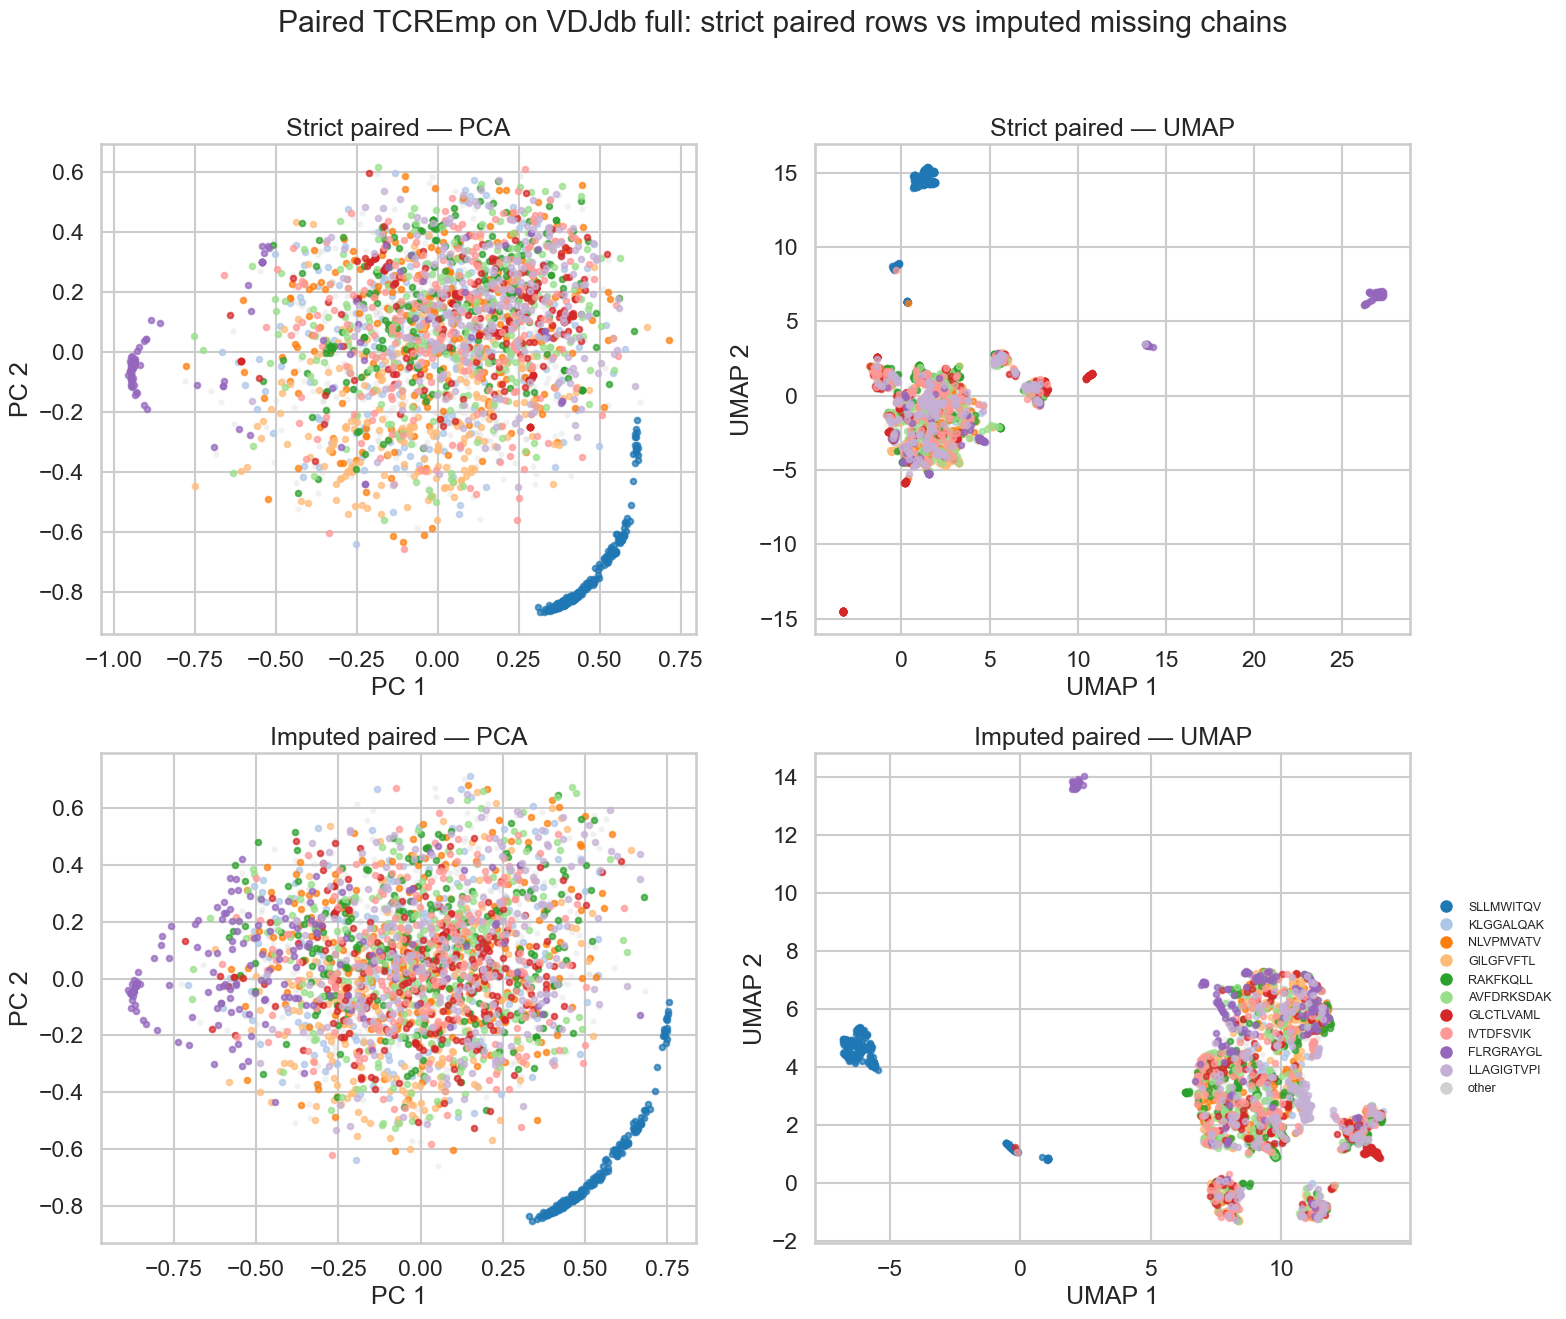

In [6]:
# Visualize paired PCA and UMAP layouts for strict and imputed modes.
palette_keys = FOCAL_EPITOPES + ['other']
palette_values = sns.color_palette('tab20', n_colors=len(FOCAL_EPITOPES)) + [(0.82, 0.82, 0.82)]
PALETTE = dict(zip(palette_keys, palette_values))

def scatter_epitopes(ax, coords, labels, title, xlabel, ylabel):
    labels = np.asarray(labels)
    mask_other = labels == 'other'
    ax.scatter(coords[mask_other, 0], coords[mask_other, 1], s=10, alpha=0.20, color=PALETTE['other'], rasterized=True)
    for epitope in FOCAL_EPITOPES:
        mask = labels == epitope
        if mask.sum() == 0:
            continue
        ax.scatter(coords[mask, 0], coords[mask, 1], s=16, alpha=0.70, color=PALETTE[epitope], rasterized=True, label=epitope)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
scatter_epitopes(axes[0, 0], strict_analysis['X_pca'][:, :2], strict_sel['epitope_cat'], 'Strict paired — PCA', 'PC 1', 'PC 2')
scatter_epitopes(axes[0, 1], strict_analysis['X_umap'], strict_sel['epitope_cat'], 'Strict paired — UMAP', 'UMAP 1', 'UMAP 2')
scatter_epitopes(axes[1, 0], imputed_analysis['X_pca'][:, :2], imputed_sel['epitope_cat'], 'Imputed paired — PCA', 'PC 1', 'PC 2')
scatter_epitopes(axes[1, 1], imputed_analysis['X_umap'], imputed_sel['epitope_cat'], 'Imputed paired — UMAP', 'UMAP 1', 'UMAP 2')

handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=8, color=PALETTE[ep], label=ep) for ep in FOCAL_EPITOPES]
handles.append(plt.Line2D([0], [0], marker='o', linestyle='', markersize=8, color=PALETTE['other'], label='other'))
axes[1, 1].legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
plt.suptitle('Paired TCREmp on VDJdb full: strict paired rows vs imputed missing chains', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Print a compact diagnostics summary for notebook execution and remaining caveats.
print('Cell diagnostics summary')
print('------------------------')
print(f'Strict loader runtime:  {strict_runtime:.2f}s')
print(f'Imputed loader runtime: {imputed_runtime:.2f}s')
print(f'Strict embed runtime:   {t_strict_embed:.3f}s')
print(f'Imputed embed runtime:  {t_imputed_embed:.3f}s')
print(f"Strict clusters/purity: {strict_analysis['n_clusters']} / {strict_analysis['purity']:.3f}")
print(f"Imputed clusters/purity:{imputed_analysis['n_clusters']} / {imputed_analysis['purity']:.3f}")
print('Risk note: imputation increases coverage but can blur antigen-specific neighborhoods when a missing chain is synthesized from shared-chain evidence.')

Cell diagnostics summary
------------------------
Strict loader runtime:  2.49s
Imputed loader runtime: 154.76s
Strict embed runtime:   0.086s
Imputed embed runtime:  0.087s
Strict clusters/purity: 1 / 0.166
Imputed clusters/purity:1 / 0.167
Risk note: imputation increases coverage but can blur antigen-specific neighborhoods when a missing chain is synthesized from shared-chain evidence.
